## Multitarget Regression

In [ ]:
import numpy as np
from sklearn.datasets import load_linnerud
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

X, y = load_linnerud(return_X_y=True)
clf = MultiOutputRegressor(Ridge(random_state=123)).fit(X, y)
clf.predict(X[[0]])

In [270]:
print(X)
print("\n")
print(y)

[[  5. 162.  60.]
 [  2. 110.  60.]
 [ 12. 101. 101.]
 [ 12. 105.  37.]
 [ 13. 155.  58.]
 [  4. 101.  42.]
 [  8. 101.  38.]
 [  6. 125.  40.]
 [ 15. 200.  40.]
 [ 17. 251. 250.]
 [ 17. 120.  38.]
 [ 13. 210. 115.]
 [ 14. 215. 105.]
 [  1.  50.  50.]
 [  6.  70.  31.]
 [ 12. 210. 120.]
 [  4.  60.  25.]
 [ 11. 230.  80.]
 [ 15. 225.  73.]
 [  2. 110.  43.]]


[[191.  36.  50.]
 [189.  37.  52.]
 [193.  38.  58.]
 [162.  35.  62.]
 [189.  35.  46.]
 [182.  36.  56.]
 [211.  38.  56.]
 [167.  34.  60.]
 [176.  31.  74.]
 [154.  33.  56.]
 [169.  34.  50.]
 [166.  33.  52.]
 [154.  34.  64.]
 [247.  46.  50.]
 [193.  36.  46.]
 [202.  37.  62.]
 [176.  37.  54.]
 [157.  32.  52.]
 [156.  33.  54.]
 [138.  33.  68.]]


## Encoding

In [259]:
from sklearn.preprocessing import LabelBinarizer

enc = LabelBinarizer()

df = pd.DataFrame([[None,"str1",3,"age1"],[4,"str2",6,"age3"],[6, "str2", None, "age1"],[2,"str3",None,"age2"],[7,'str1',5,"age2"],[8,"str4",None,"age3"],[None, "str2", 10, "age3"]],columns=["a","b","c","d"])

print(df)
print("\n")
X_train = df.iloc[0:4,:]
X_test = df.iloc[4:,:]

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)


for feature in ["b","d"]:
    if(X_train[feature].dtypes)=='object':
        enc.fit(X_train[feature])
        X_train_tr = enc.transform(X_train[feature])
        X_test_tr = enc.transform(X_test[feature])

        dim = X_train_tr.shape[1]
        new_name = [feature + "_" + str(i+1) for i in range(dim)]

        X_train_tr_df = pd.DataFrame(X_train_tr, columns=new_name)
        X_test_tr_df = pd.DataFrame(X_test_tr, columns=new_name)

        X_train = pd.concat([X_train, X_train_tr_df], axis=1)
        X_test = pd.concat([X_test, X_test_tr_df], axis=1)

        X_train.drop(feature, axis=1, inplace=True)
        X_test.drop(feature, axis=1, inplace= True)

# X_train.drop(["b","d"], axis=1, inplace=True)
#X_test.drop(["b","d"], axis=1, inplace= True)

print(X_train)
print(X_test)

     a     b     c     d
0  NaN  str1   3.0  age1
1  4.0  str2   6.0  age3
2  6.0  str2   NaN  age1
3  2.0  str3   NaN  age2
4  7.0  str1   5.0  age2
5  8.0  str4   NaN  age3
6  NaN  str2  10.0  age3


     a    c  b_1  b_2  b_3  d_1  d_2  d_3
0  NaN  3.0    1    0    0    1    0    0
1  4.0  6.0    0    1    0    0    0    1
2  6.0  NaN    0    1    0    1    0    0
3  2.0  NaN    0    0    1    0    1    0
     a     c  b_1  b_2  b_3  d_1  d_2  d_3
0  7.0   5.0    1    0    0    0    1    0
1  8.0   NaN    0    0    0    0    0    1
2  NaN  10.0    0    1    0    0    0    1


## Imputing

In [260]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="mean")

imp.fit(X_train)

names = X_train.columns

X_train = pd.DataFrame(imp.transform(X_train),columns=names)
X_test = pd.DataFrame(imp.transform(X_test),columns=names)

print(X_train)
print(X_test)

     a    c  b_1  b_2  b_3  d_1  d_2  d_3
0  4.0  3.0  1.0  0.0  0.0  1.0  0.0  0.0
1  4.0  6.0  0.0  1.0  0.0  0.0  0.0  1.0
2  6.0  4.5  0.0  1.0  0.0  1.0  0.0  0.0
3  2.0  4.5  0.0  0.0  1.0  0.0  1.0  0.0
     a     c  b_1  b_2  b_3  d_1  d_2  d_3
0  7.0   5.0  1.0  0.0  0.0  0.0  1.0  0.0
1  8.0   4.5  0.0  0.0  0.0  0.0  0.0  1.0
2  4.0  10.0  0.0  1.0  0.0  0.0  0.0  1.0


## Scaling

In [261]:
from sklearn.preprocessing import Normalizer

sc = Normalizer()

sc.fit(X_train)

names = X_train.columns

X_train = pd.DataFrame(sc.transform(X_train),columns=names)
X_test = pd.DataFrame(sc.transform(X_test),columns=names)

print(X_train)
print(X_test)

          a         c      b_1       b_2      b_3       d_1      d_2       d_3
0  0.769800  0.577350  0.19245  0.000000  0.00000  0.192450  0.00000  0.000000
1  0.544331  0.816497  0.00000  0.136083  0.00000  0.000000  0.00000  0.136083
2  0.786146  0.589610  0.00000  0.131024  0.00000  0.131024  0.00000  0.000000
3  0.390360  0.878310  0.00000  0.000000  0.19518  0.000000  0.19518  0.000000
          a         c       b_1       b_2  b_3  d_1       d_2       d_3
0  0.802955  0.573539  0.114708  0.000000  0.0  0.0  0.114708  0.000000
1  0.866449  0.487377  0.000000  0.000000  0.0  0.0  0.000000  0.108306
2  0.368230  0.920575  0.000000  0.092057  0.0  0.0  0.000000  0.092057


In [266]:
sum(X_train.values[0]**2)

1.0000000000000002

## Feature selection

In [358]:
file_name = "~/deep_sim/pydeep_sim/tests/integration_tests/input_files/ml_inputs/simulation_output_Rough_Surface_Contact_Automatized_Simulation.dat"


res = {"filepath_or_buffer":file_name, "sep":"\t"}

df = getattr(pd, 'read_csv')(**res)
df.drop(["E1", "nu1", "E2", "nu2", "lato", "g0", "Delta", "errf", "tol", "total_force"],inplace=True, axis=1)
df.head()

,total_cont_area,mean_z_peaks,rms_z_peaks,ks_z_peaks,sk_z_peaks,mean_curv_peaks,ks_curv_peaks,sk_curv_peaks,dn_peaks,alfa_x,...,sk_z_asp,mean_curv_asp,rms_curv_asp,ks_curv_asp,sk_curv_asp,dns_asp,z_mean,z_rms,H,n
0,0.16225,24.47322,6.93093,2.54576,0.09094,0.05462,0.45438,0.73141,0.25954,6.93854,...,0.07198,0.05967,0.02560,3.18826,0.56869,0.12313,22.97980,7.01089,0.50612,7
1,0.34066,25.67699,8.40073,2.55247,-0.27467,0.07289,0.81979,0.80722,0.22071,33.18974,...,-0.28044,0.08169,0.03634,4.06441,0.80180,0.09257,24.96240,8.44335,0.77551,8
2,0.18923,24.92936,8.55020,2.57842,-0.18751,0.22397,0.57074,0.74897,0.23771,70.19310,...,-0.18889,0.24955,0.10828,3.60061,0.68319,0.10396,24.50014,8.58030,0.68367,9
3,0.55111,26.49648,8.02346,2.40325,-0.19575,0.14114,0.58453,0.74868,0.24721,13.95965,...,-0.21949,0.15586,0.06731,3.57437,0.65461,0.11414,25.49236,8.07536,0.61633,8
4,0.09918,21.39933,7.44647,2.82704,0.05259,0.24335,0.84666,0.79021,0.23408,49.48499,...,0.03928,0.27157,0.11853,4.03361,0.77073,0.10221,20.85471,7.43215,0.70816,9


In [359]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop("total_cont_area", axis=1), df["total_cont_area"], train_size=0.8, random_state=40)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(797, 23)
(200, 23)
(797,)
(200,)


In [360]:
from sklearn.preprocessing import Normalizer

sc = Normalizer(norm='l2')

sc.fit(X_train)

names = X_train.columns

X_train_sc = pd.DataFrame(sc.transform(X_train),columns=names)
X_test_sc = pd.DataFrame(sc.transform(X_test),columns=names)

In [375]:
X_train_sc

,mean_z_peaks,rms_z_peaks,ks_z_peaks,sk_z_peaks,mean_curv_peaks,ks_curv_peaks,sk_curv_peaks,dn_peaks,alfa_x,alfa_y,...,sk_z_asp,mean_curv_asp,rms_curv_asp,ks_curv_asp,sk_curv_asp,dns_asp,z_mean,z_rms,H,n
0,0.464017,0.146130,0.044248,-0.001418,0.001561,0.014940,0.014564,0.003932,0.373701,0.359165,...,-0.001141,0.001771,0.000792,0.071891,0.014593,0.001627,0.451111,0.146295,0.014109,0.143279
1,0.236781,0.084776,0.027587,0.002986,0.003057,0.005802,0.007776,0.002707,0.622707,0.642459,...,0.003085,0.003386,0.001450,0.036255,0.006558,0.001264,0.231161,0.084937,0.005712,0.094697
2,0.531636,0.172187,0.052102,0.007618,0.001083,0.005818,0.013783,0.005187,0.158125,0.167024,...,0.008686,0.001179,0.000494,0.061552,0.010089,0.002440,0.500393,0.173946,0.012021,0.145180
3,0.472780,0.105091,0.055169,-0.005588,0.001365,0.013671,0.012779,0.003850,0.348612,0.393257,...,-0.005933,0.001522,0.000667,0.066600,0.012309,0.001640,0.460211,0.107935,0.012260,0.133867
4,0.314296,0.090233,0.028635,0.001177,0.003452,0.005476,0.008092,0.002858,0.583756,0.572330,...,0.001204,0.003800,0.001633,0.038851,0.007141,0.001337,0.308010,0.090236,0.006385,0.101279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792,0.438548,0.143853,0.040430,0.004510,0.008315,0.007578,0.012175,0.004426,0.402747,0.419761,...,0.004505,0.009161,0.003911,0.058351,0.010669,0.002105,0.424311,0.144357,0.008762,0.152119
793,0.541935,0.164031,0.068547,0.002675,0.001429,0.002947,0.014493,0.005835,0.105206,0.111249,...,0.003188,0.001574,0.000672,0.073670,0.013628,0.002834,0.503124,0.165351,0.011671,0.157602
794,0.489555,0.156938,0.077958,0.011540,0.003195,0.008656,0.014894,0.005582,0.296090,0.294634,...,0.011356,0.003527,0.001489,0.072580,0.012635,0.002661,0.468277,0.157842,0.011703,0.174433
795,0.391852,0.108795,0.035528,0.004738,0.000915,0.018039,0.012369,0.003050,0.509927,0.478836,...,0.005287,0.001030,0.000464,0.063699,0.012456,0.001292,0.382776,0.110104,0.010936,0.111058


## Correlation matrix

In [372]:
correlation = X_train_sc.corrwith(y_train,method='pearson')
print(correlation)

mean_z_peaks       0.246065
rms_z_peaks        0.152392
ks_z_peaks        -0.049583
sk_z_peaks        -0.369443
mean_curv_peaks   -0.437470
ks_curv_peaks      0.111758
sk_curv_peaks      0.027690
dn_peaks          -0.062656
alfa_x            -0.251552
alfa_y            -0.258919
mean_z_asp         0.245688
rms_z_asp          0.152637
ks_z_asp          -0.096695
sk_z_asp          -0.360506
mean_curv_asp     -0.438580
rms_curv_asp      -0.440215
ks_curv_asp        0.062400
sk_curv_asp        0.086471
dns_asp           -0.091158
z_mean             0.250195
z_rms              0.155670
H                  0.134859
n                 -0.166879
dtype: float64


614    0.47692
137    0.15465
82     0.81125
188    0.34823
358    0.42634
        ...   
440    0.31919
165    0.24638
7      0.22105
219    1.13703
326    0.49963
Name: total_cont_area, Length: 797, dtype: float64

In [320]:
correlation[abs(correlation)>0.1]

mean_z_peaks       0.445476
rms_z_peaks        0.293668
ks_z_peaks        -0.139121
sk_z_peaks        -0.209843
mean_curv_peaks   -0.419918
dn_peaks          -0.205371
alfa_x            -0.164988
alfa_y            -0.166420
mean_z_asp         0.455751
rms_z_asp          0.292539
ks_z_asp          -0.138646
sk_z_asp          -0.204615
mean_curv_asp     -0.419818
rms_curv_asp      -0.419635
sk_curv_asp        0.108696
dns_asp           -0.178695
z_mean             0.423745
z_rms              0.310363
H                  0.162141
n                 -0.432429
dtype: float64

In [326]:
correlation[abs(correlation)>0.1].index

Index(['mean_z_peaks', 'rms_z_peaks', 'ks_z_peaks', 'sk_z_peaks',
       'mean_curv_peaks', 'dn_peaks', 'alfa_x', 'alfa_y', 'mean_z_asp',
       'rms_z_asp', 'ks_z_asp', 'sk_z_asp', 'mean_curv_asp', 'rms_curv_asp',
       'sk_curv_asp', 'dns_asp', 'z_mean', 'z_rms', 'H', 'n'],
      dtype='object')

In [327]:
X_train = X_train[correlation[abs(correlation)>0.1].index]

In [328]:
X_train.shape

(797, 20)

## Feature Selection: Correlation matrix

<AxesSubplot:>

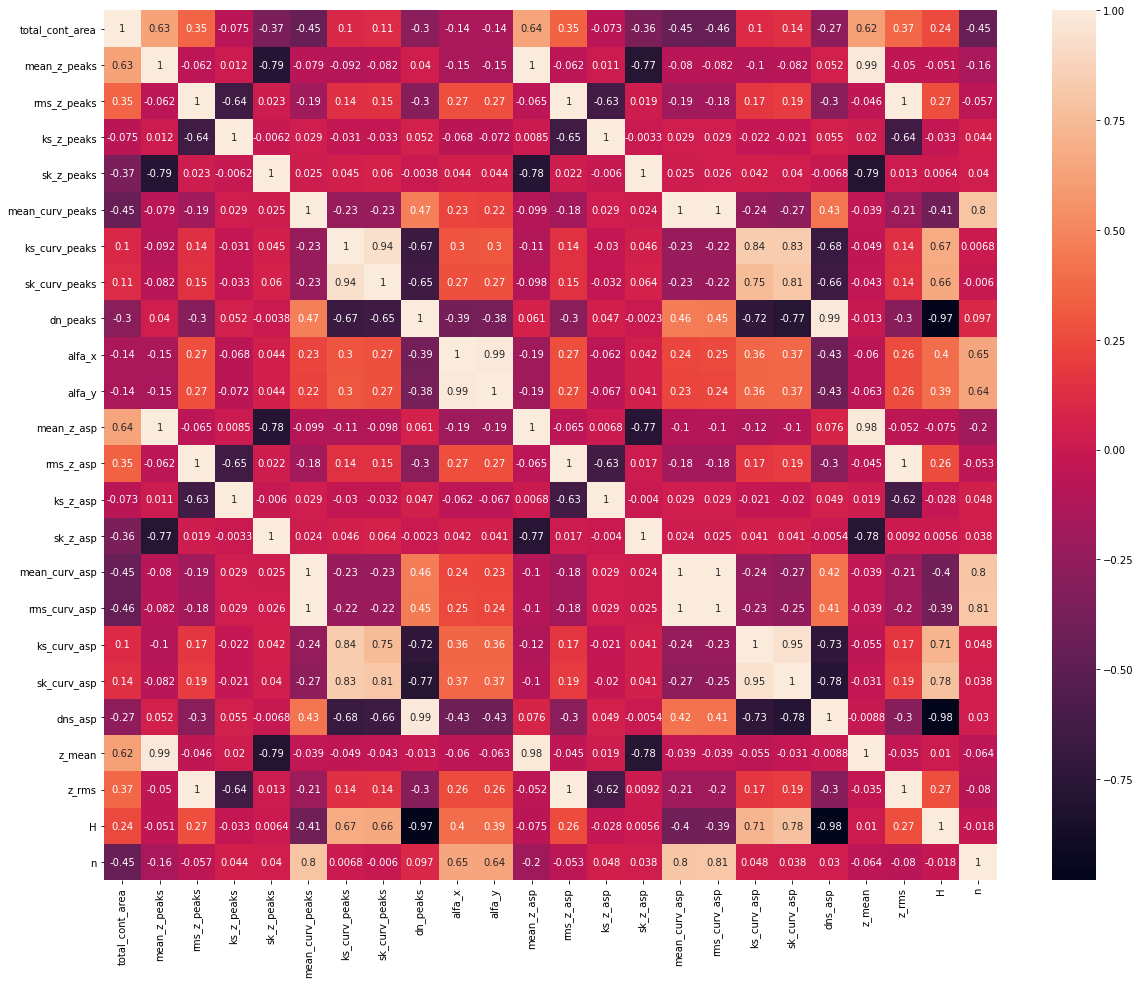

In [275]:
import seaborn as sns 
import matplotlib.pyplot as plt 
#%matplotlib inline
import pandas as pd 

cor = df.corr()

plt.figure(figsize=(20,16))
sns.heatmap(cor,annot=True)


## Grid Search

In [6]:
import pandas as pd


In [8]:
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV
iris = datasets.load_iris()
parameters = {'kernel':['linear', 'rbf'], 'C':[1, 10]}
svc = svm.SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(iris.data, iris.target)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10], 'kernel': ['linear', 'rbf']})

In [9]:
pd.DataFrame(clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000729,0.000061,0.000299,0.000022,1,linear,"{'C': 1, 'kernel': 'linear'}",0.966667,1.000000,0.966667,0.966667,1.0,0.980000,0.016330,1
1,0.000679,0.000027,0.000324,0.000008,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.966667,0.966667,0.966667,0.933333,1.0,0.966667,0.021082,4
2,0.000564,0.000026,0.000253,0.000008,10,linear,"{'C': 10, 'kernel': 'linear'}",1.000000,1.000000,0.900000,0.966667,1.0,0.973333,0.038873,3
3,0.000573,0.000016,0.000274,0.000003,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.966667,1.000000,0.966667,0.966667,1.0,0.980000,0.016330,1


In [13]:
from xgboost import XGBRegressor
from sklearn import datasets
from sklearn.model_selection import GridSearchCV
iris = datasets.load_iris()
parameters = {"colsample_bytree":[0.3], "learning_rate":[0.1], "max_depth":[5], "alpha":[10], "n_estimators":[10]}
xg = XGBRegressor(colsample_bytree=0.3)
clf = GridSearchCV(xg, parameters)
clf.fit(iris.data, iris.target)

GridSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                    colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, gamma=None,
                                    gpu_id=None, importance_type='gain',
                                    interaction_constraints=None,
                                    learning_rate=None, max_delta_step=None,
                                    max_depth=None, min_child_weight=None,
                                    missing=nan, monotone_constraints=None,
                                    n_estimators=100, n_jobs=None,
                                    num_parallel_tree=None, random_state=None,
                                    reg_alpha=None, reg_lambda=None,
                                    scale_pos_weight=None, subsample=None,
                                    tree_method=None, validate_parameters=None,
      

In [14]:
pd.DataFrame(clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.069101,0.125787,0.001728,0.000162,10,0.3,0.1,5,10,"{'alpha': 10, 'colsample_bytree': 0.3, 'learni...",0.0,0.306836,0.0,-1.883679,0.0,-0.315369,0.793109,1


In [6]:
from xgboost import XGBRegressor
from sklearn import datasets
from sklearn.model_selection import GridSearchCV
import pandas as pd
iris = datasets.load_iris()
parameters = {"learning_rate":[0.1,0.2,0.3], "max_depth":[5,6,8], "alpha":[10]}
xg = XGBRegressor(n_estimators=10)
clf = GridSearchCV(xg, param_grid=parameters)
clf.fit(iris.data, iris.target)

GridSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                    colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, gamma=None,
                                    gpu_id=None, importance_type='gain',
                                    interaction_constraints=None,
                                    learning_rate=None, max_delta_step=None,
                                    max_depth=None, min_child_weight=None,
                                    missing=nan, monotone_constraints=None,
                                    n_estimators=10, n_jobs=None,
                                    num_parallel_tree=None, random_state=None,
                                    reg_alpha=None, reg_lambda=None,
                                    scale_pos_weight=None, subsample=None,
                                    tree_method=None, validate_parameters=None,
       

In [14]:
emppy = {"base_score":10}
xg.set_params(**emppy)

XGBRegressor(base_score=10, booster=None, colsample_bylevel=None,
             colsample_bynode=None, colsample_bytree=None, gamma=None,
             gpu_id=None, importance_type='gain', interaction_constraints=None,
             learning_rate=None, max_delta_step=None, max_depth=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=10, n_jobs=None, num_parallel_tree=None,
             random_state=None, reg_alpha=None, reg_lambda=None,
             scale_pos_weight=None, subsample=None, tree_method=None,
             validate_parameters=None, verbosity=None)

In [15]:
xg

XGBRegressor(base_score=10, booster=None, colsample_bylevel=None,
             colsample_bynode=None, colsample_bytree=None, gamma=None,
             gpu_id=None, importance_type='gain', interaction_constraints=None,
             learning_rate=None, max_delta_step=None, max_depth=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=10, n_jobs=None, num_parallel_tree=None,
             random_state=None, reg_alpha=None, reg_lambda=None,
             scale_pos_weight=None, subsample=None, tree_method=None,
             validate_parameters=None, verbosity=None)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_learning_rate,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.060280,0.075218,0.007704,0.003723,10,0.1,5,"{'alpha': 10, 'learning_rate': 0.1, 'max_depth...",0.0,0.496904,0.0,-1.523543,0.0,-0.205328,0.686629,7
1,0.076271,0.137514,0.001974,0.000135,10,0.1,6,"{'alpha': 10, 'learning_rate': 0.1, 'max_depth...",0.0,0.496904,0.0,-1.523543,0.0,-0.205328,0.686629,7
2,0.003945,0.000448,0.001725,0.000009,10,0.1,8,"{'alpha': 10, 'learning_rate': 0.1, 'max_depth...",0.0,0.496904,0.0,-1.523543,0.0,-0.205328,0.686629,7
3,0.003931,0.000373,0.001708,0.000014,10,0.2,5,"{'alpha': 10, 'learning_rate': 0.2, 'max_depth...",0.0,0.592001,0.0,-0.193040,0.0,0.079792,0.266794,4
4,0.003856,0.000206,0.002063,0.000611,10,0.2,6,"{'alpha': 10, 'learning_rate': 0.2, 'max_depth...",0.0,0.592001,0.0,-0.193040,0.0,0.079792,0.266794,4
5,0.003836,0.000208,0.001999,0.000583,10,0.2,8,"{'alpha': 10, 'learning_rate': 0.2, 'max_depth...",0.0,0.592001,0.0,-0.193040,0.0,0.079792,0.266794,4
6,0.004004,0.000446,0.001833,0.000175,10,0.3,5,"{'alpha': 10, 'learning_rate': 0.3, 'max_depth...",0.0,0.608918,0.0,0.204634,0.0,0.162710,0.236763,1
7,0.005396,0.002851,0.002743,0.001738,10,0.3,6,"{'alpha': 10, 'learning_rate': 0.3, 'max_depth...",0.0,0.608918,0.0,0.204634,0.0,0.162710,0.236763,1
8,0.004180,0.000333,0.005114,0.003061,10,0.3,8,"{'alpha': 10, 'learning_rate': 0.3, 'max_depth...",0.0,0.608918,0.0,0.204634,0.0,0.162710,0.236763,1


In [8]:
clf.best_estimator_

XGBRegressor(alpha=10, base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.3, max_delta_step=0, max_depth=5,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=10, n_jobs=12, num_parallel_tree=1, random_state=0,
             reg_alpha=10, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [7]:
clf.best_estimator_

XGBRegressor(alpha=10, base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=0.8, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.3, max_delta_step=0, max_depth=5,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=10, n_jobs=12, num_parallel_tree=1, random_state=0,
             reg_alpha=10, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [8]:
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
X, y = make_regression(n_samples=200, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=1)
regr = MLPRegressor(random_state=1, max_iter=2000).fit(X_train, y_train)